In [1]:
import gc
import argparse
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import muspan as ms



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/sarapatti/miniforge3/envs/muspan/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Users/sarapatti/miniforge3/envs/muspan/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/Users/sarapatti/miniforge3/envs/muspan/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 739, in

In [2]:
# Load the domain inside the worker process
domain = ms.io.load_domain("/Volumes/phenotypingsputumasthmaticsaurorawellcomea1/live/Sara_Patti/009_ST_Xenium/output/muspan/domains/IPF_RBH_16_muspan_domain.muspan")

MuSpAn domain loaded successfully. Domain summary:
Domain name: IPF_RBH_16
Number of objects: 202636
Collections: ['Cell boundaries', 'Nucleus boundaries', 'Transcripts', 'Cell centroids']
Labels: ['Cell ID', 'Transcript Counts', 'Cell Area', 'Nucleus Area', 'Transcript ID', 'Cell Type'] 
Networks: ['Delaunay CC', 'Delaunay CC filtered', 'Proximity_30um'] 
Distance matrices: []


In [12]:
qTrans = ms.query.query(domain, ('Collection',), 'is', 'Transcripts')
boundCells = ms.query.query(domain, ("Collection",), "is", "Cell boundaries")
query_16S = ms.query.query(domain, ('label', 'Transcript ID'), 'is', '16S')

In [ ]:
# Visualise transcripts, colored by 'Transcript'
fig, ax = plt.subplots(figsize=(20, 12))
ms.visualise.visualise(
        domain,
        color_by=("label", "Cell Type"),
        objects_to_plot=boundCells,
        shape_kwargs=dict(alpha=1, linewidth=0.005, edgecolor="#00000000"), ax=ax
    )
ms.visualise.visualise(domain, color_by=("label", "Transcript ID"), objects_to_plot=query_16S, marker_size=0.005, ax=ax, shape_kwargs=dict(color = "#ee7976"))

plt.savefig("/Volumes/phenotypingsputumasthmaticsaurorawellcomea1/live/Sara_Patti/009_ST_Xenium/output/16S/muspan/16S_IPF16.pdf", dpi=600)
plt.savefig("/Volumes/phenotypingsputumasthmaticsaurorawellcomea1/live/Sara_Patti/009_ST_Xenium/output/16S/muspan/16S_IPF16.png", dpi=600)

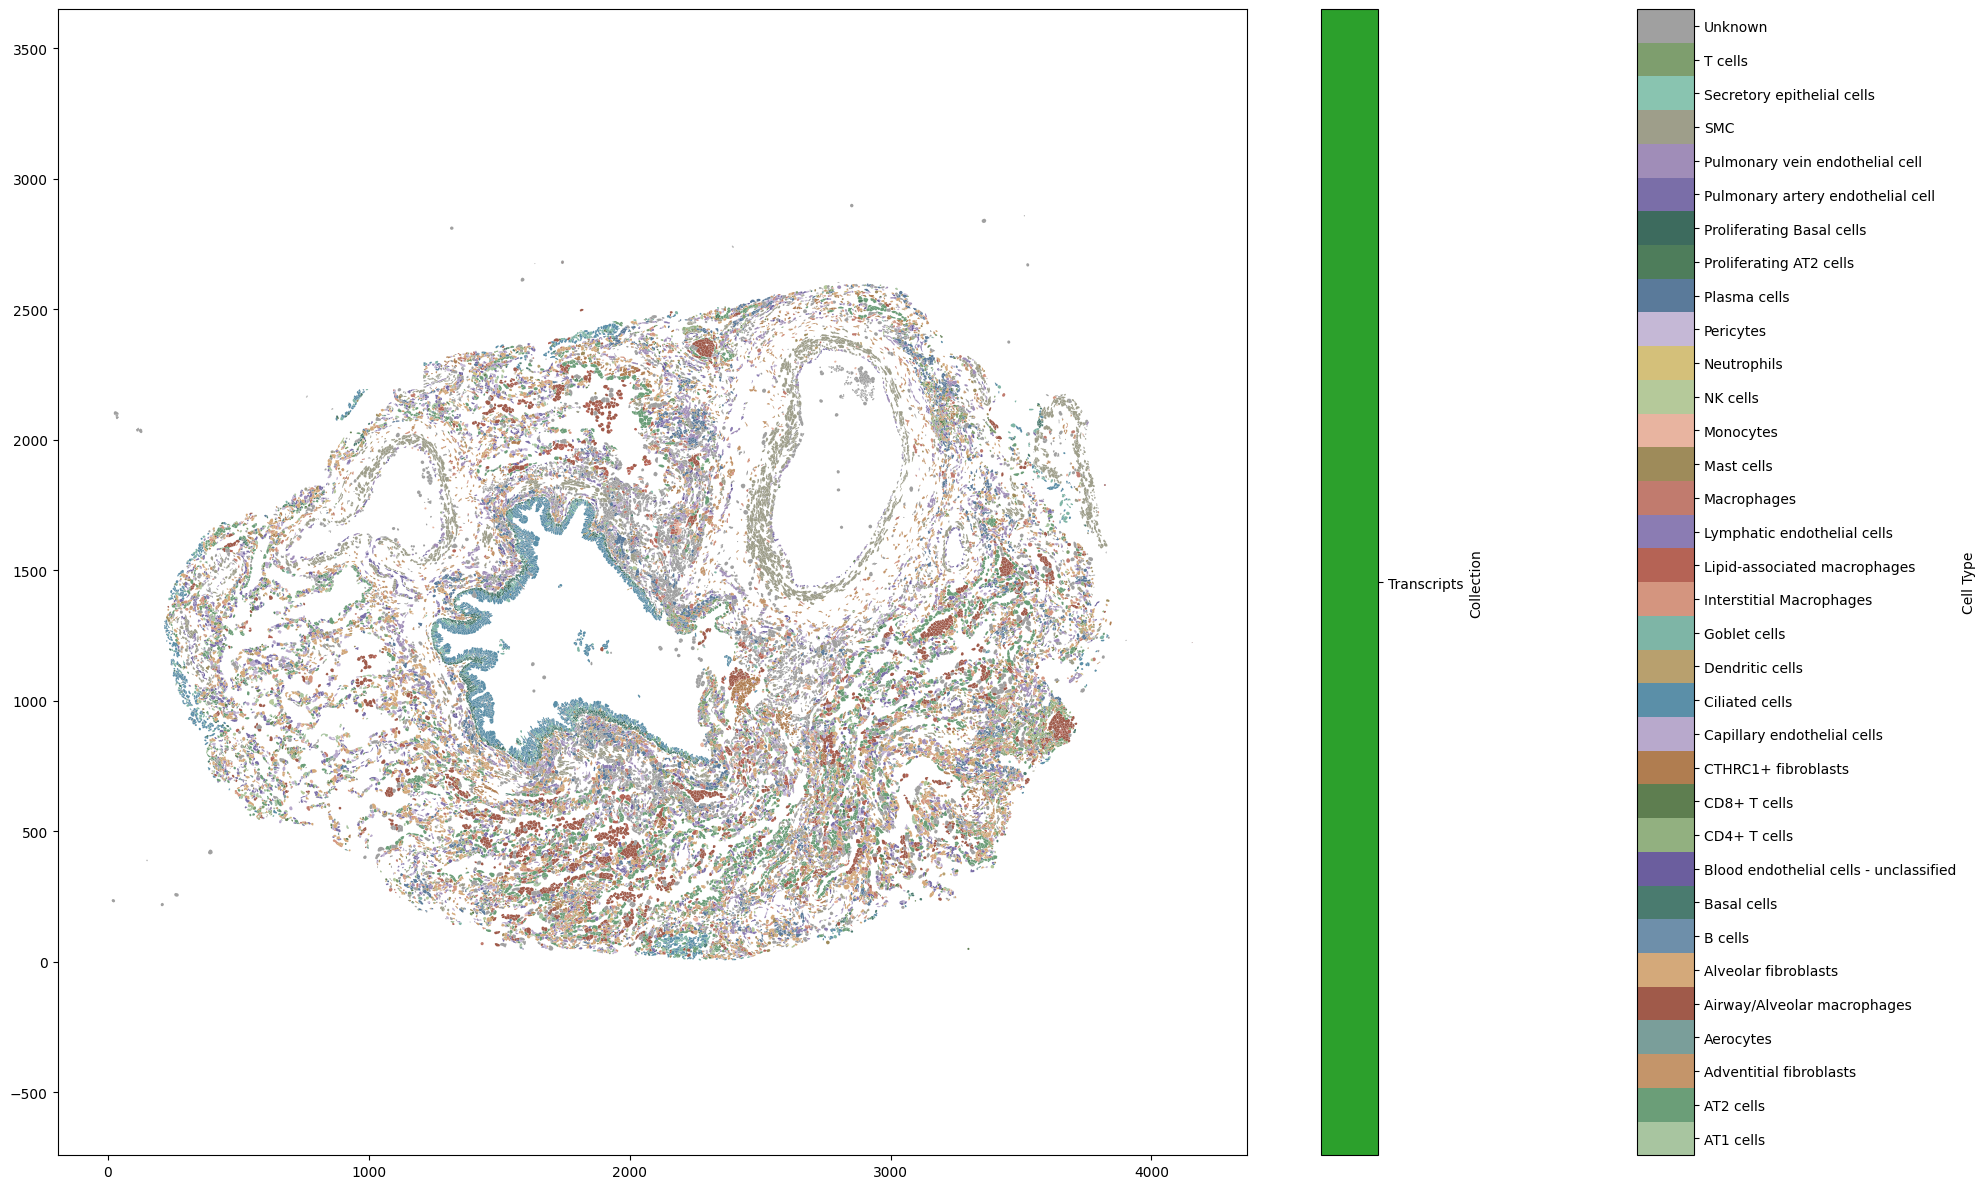

In [ ]:
# Plot cells
fig, ax = plt.subplots(figsize=(20, 12))
# ms.visualise.visualise(
#     domain,
#     color_by=("label", "Cell Type"),
#     objects_to_plot=boundCells,
#     shape_kwargs=dict(alpha=1, linewidth=0.005, edgecolor="#00000000"),
#     ax=ax,
# )

# Plot 16S transcripts
ms.visualise.visualise(
    domain,
    objects_to_plot=query_16S,
    marker_size=5,
    ax=ax,
)

# The 16S points are the PathCollection; cells are PathPatches
for coll in ax.collections:
    coll.set_array(None)
    coll.set_facecolors("#ee7976")
    coll.set_edgecolors("none")
    coll.set_rasterized(True)  # fix PDF marker size

# plt.savefig("16S_IPF16.pdf", dpi=600)
# plt.savefig("16S_IPF16.png", dpi=600)